# Motif Code

## Exp 1

### Main Code

In [25]:
# ============================================================
# Cell 1: Run experiments and save CSV outputs
# ============================================================

import os
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# Hyperparameters and parameters
# ============================================================

SEED = 42                 # Global random seed for reproducibility
ROW = 100                 # Number of regions
COL = 16                   # Number of subregions per region
EXP_DIR = "exp1"          # Output folder for Experiment 1

N_SWAPS = 100             # Number of random pair swaps in context matrix C
NOISE_STD = 0.1          # Gaussian noise added to Y

N_EPOCHS = 4000           # Number of training epochs
LR = 1e-3                 # Learning rate
WEIGHT_DECAY = 1e-3       # AdamW weight decay for regularization
HIDDEN_DIM = 32           # Hidden layer width
DROPOUT = 0.05            # Dropout probability
PRINT_INTERVAL = 10       # Print loss every n epochs

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# ============================================================
# Reproducibility
# ============================================================

def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


set_all_seeds(SEED)


# ============================================================
# Validation
# ============================================================

def is_perfect_square(x):
    r = int(math.sqrt(x))
    return r * r == x


if not is_perfect_square(ROW):
    raise ValueError(f"ROW={ROW} must be a perfect square.")

if not is_perfect_square(COL):
    raise ValueError(f"COL={COL} must be a perfect square.")


os.makedirs(EXP_DIR, exist_ok=True)


# ============================================================
# Ground-truth function f(t, c)
# ============================================================

def true_f_numpy(t, c):
    """
    Ground-truth function.

    If t == 0:
        f = 1

    If t == 1:
        f is given by piecewise linear interpolation over c
        using anchor points:
            (-100, 2), (-2, 2), (0, 1), (1, 0), (100, 0)
    """
    t = np.asarray(t)
    c = np.asarray(c)

    anchor_x = np.array([-100, -2, 0, 1, 100], dtype=float)
    anchor_y = np.array([2, 2, 1, 0, 0], dtype=float)

    y_t1 = np.interp(c, anchor_x, anchor_y)
    y = np.where(t == 0, 1.0, y_t1)

    return y.astype(float)


# ============================================================
# Data generation
# ============================================================

def create_treatment_matrix(row, col):
    """
    Create treatment matrix T.

    Exactly half of the rows are all ones and half are all zeros.
    """
    if row % 2 != 0:
        raise ValueError("ROW must be even to assign exactly half treated rows.")

    row_flags = np.array([1] * (row // 2) + [0] * (row // 2))
    np.random.shuffle(row_flags)

    T = np.repeat(row_flags[:, None], col, axis=1)

    return T.astype(float)


def create_context_matrix(row, col, n_swaps):
    """
    Create context matrix C.

    1. Draw all entries from a normal distribution.
    2. Subtract the row mean so each row sums to zero.
    3. Randomly swap n_swaps pairs of entries.
    """
    C = np.random.normal(loc=0.0, scale=1.0, size=(row, col))
    C = C - C.mean(axis=1, keepdims=True)

    for _ in range(n_swaps):
        r1 = np.random.randint(0, row)
        c1 = np.random.randint(0, col)

        r2 = np.random.randint(0, row)
        c2 = np.random.randint(0, col)

        C[r1, c1], C[r2, c2] = C[r2, c2], C[r1, c1]

    return C.astype(float)


T = create_treatment_matrix(ROW, COL)
C = create_context_matrix(ROW, COL, N_SWAPS)

Y_clean = true_f_numpy(T, C)
Y = Y_clean + np.random.normal(loc=0.0, scale=NOISE_STD, size=(ROW, COL))

T_agg = T.mean(axis=1)
C_agg = C.mean(axis=1)
Y_agg = Y.mean(axis=1)

Y_disagg = np.repeat(Y_agg[:, None], COL, axis=1)

E_true = true_f_numpy(T, C) - true_f_numpy(np.zeros_like(T), C)


# ============================================================
# Save generated data
# ============================================================

pd.DataFrame(T).to_csv(os.path.join(EXP_DIR, "T.csv"), index=False, header=False)
pd.DataFrame(C).to_csv(os.path.join(EXP_DIR, "C.csv"), index=False, header=False)
pd.DataFrame(Y).to_csv(os.path.join(EXP_DIR, "Y.csv"), index=False, header=False)
pd.DataFrame(Y_clean).to_csv(os.path.join(EXP_DIR, "Y_clean.csv"), index=False, header=False)

pd.DataFrame(T_agg).to_csv(os.path.join(EXP_DIR, "T_agg.csv"), index=False, header=False)
pd.DataFrame(C_agg).to_csv(os.path.join(EXP_DIR, "C_agg.csv"), index=False, header=False)
pd.DataFrame(Y_agg).to_csv(os.path.join(EXP_DIR, "Y_agg.csv"), index=False, header=False)

pd.DataFrame(Y_disagg).to_csv(os.path.join(EXP_DIR, "Y_disagg.csv"), index=False, header=False)
pd.DataFrame(E_true).to_csv(os.path.join(EXP_DIR, "LOCATE_true.csv"), index=False, header=False)


# ============================================================
# Model
# ============================================================

class SmallMLP(nn.Module):
    """
    Simple neural network approximating f(t, c).
    """
    def __init__(self, hidden_dim=64, dropout=0.05):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def make_features(T, C):
    """
    Convert T and C matrices into feature tensor with shape ROW x COL x 2.
    """
    X = np.stack([T, C], axis=-1)
    return X.astype(np.float32)


def predict_matrix(model, T_np, C_np):
    """
    Predict element-wise outcome matrix using model f_rec(t, c).
    """
    model.eval()

    X_np = make_features(T_np, C_np)
    X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        pred = model(X_t.reshape(-1, 2)).reshape(T_np.shape)

    return pred.detach().cpu().numpy()


def compute_locate_matrix(model, T_np, C_np):
    """
    Compute LOCATE:
        E_ij = f_rec(t_ij, c_ij) - f_rec(0, c_ij)
    """
    Y_treated_or_observed = predict_matrix(model, T_np, C_np)
    Y_control = predict_matrix(model, np.zeros_like(T_np), C_np)

    return Y_treated_or_observed - Y_control


def compute_locate_mae_torch(model, T_t, C_t, E_true_t):
    """
    Compute current LOCATE MAE during training.
    """
    X_obs = torch.stack([T_t, C_t], dim=-1)
    X_zero = torch.stack([torch.zeros_like(T_t), C_t], dim=-1)

    pred_obs = model(X_obs.reshape(-1, 2)).reshape(T_t.shape)
    pred_zero = model(X_zero.reshape(-1, 2)).reshape(T_t.shape)

    E_pred = pred_obs - pred_zero
    locate_mae = torch.mean(torch.abs(E_pred - E_true_t))

    return locate_mae


# ============================================================
# Experiment 1a: aggregated loss signal
# ============================================================

def train_exp1a(T, C, Y, Y_agg, E_true):
    """
    Train f_rec using only row-aggregated outcome loss.
    """
    set_all_seeds(SEED)

    model = SmallMLP(hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    X_np = make_features(T, C)

    X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
    T_t = torch.tensor(T, dtype=torch.float32, device=DEVICE)
    C_t = torch.tensor(C, dtype=torch.float32, device=DEVICE)
    Y_t = torch.tensor(Y, dtype=torch.float32, device=DEVICE)
    Y_agg_t = torch.tensor(Y_agg, dtype=torch.float32, device=DEVICE)
    E_true_t = torch.tensor(E_true, dtype=torch.float32, device=DEVICE)

    history = []

    for epoch in range(1, N_EPOCHS + 1):
        model.train()

        pred = model(X_t.reshape(-1, 2)).reshape(ROW, COL)
        pred_agg = pred.mean(dim=1)

        loss = torch.mean((pred_agg - Y_agg_t) ** 2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            prediction_error = torch.mean((pred - Y_t) ** 2)
            locate_mae = compute_locate_mae_torch(model, T_t, C_t, E_true_t)

        history.append({
            "epoch": epoch,
            "training_loss": loss.item(),
            "prediction_error": prediction_error.item(),
            "locate_mae": locate_mae.item(),
        })

        if epoch % PRINT_INTERVAL == 0 or epoch == 1:
            print(
                f"[Exp 1a] Epoch {epoch:04d} | "
                f"loss={loss.item():.6f} | "
                f"prediction_error={prediction_error.item():.6f} | "
                f"locate_mae={locate_mae.item():.6f}"
            )

    return model, pd.DataFrame(history)


model_1a, hist_1a = train_exp1a(T, C, Y, Y_agg, E_true)

Y_rec_1a = predict_matrix(model_1a, T, C)
E_1a = compute_locate_matrix(model_1a, T, C)

hist_1a.to_csv(os.path.join(EXP_DIR, "history_1a.csv"), index=False)
pd.DataFrame(Y_rec_1a).to_csv(os.path.join(EXP_DIR, "Y_rec_1a.csv"), index=False, header=False)
pd.DataFrame(E_1a).to_csv(os.path.join(EXP_DIR, "LOCATE_1a.csv"), index=False, header=False)


# ============================================================
# Experiment 1b: uniform disaggregation baseline
# ============================================================

def train_exp1b(T, C, Y, Y_disagg, E_true):
    """
    Train f_rec2 on uniformly disaggregated outcomes.

    Here the loss is available for every element, but the target is naive.
    """
    set_all_seeds(SEED)

    model = SmallMLP(hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    X_np = make_features(T, C)

    X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
    T_t = torch.tensor(T, dtype=torch.float32, device=DEVICE)
    C_t = torch.tensor(C, dtype=torch.float32, device=DEVICE)
    Y_t = torch.tensor(Y, dtype=torch.float32, device=DEVICE)
    Y_disagg_t = torch.tensor(Y_disagg, dtype=torch.float32, device=DEVICE)
    E_true_t = torch.tensor(E_true, dtype=torch.float32, device=DEVICE)

    history = []

    for epoch in range(1, N_EPOCHS + 1):
        model.train()

        pred = model(X_t.reshape(-1, 2)).reshape(ROW, COL)

        loss = torch.mean((pred - Y_disagg_t) ** 2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            prediction_error = torch.mean((pred - Y_t) ** 2)
            locate_mae = compute_locate_mae_torch(model, T_t, C_t, E_true_t)

        history.append({
            "epoch": epoch,
            "training_loss": loss.item(),
            "prediction_error": prediction_error.item(),
            "locate_mae": locate_mae.item(),
        })

        if epoch % PRINT_INTERVAL == 0 or epoch == 1:
            print(
                f"[Exp 1b] Epoch {epoch:04d} | "
                f"loss={loss.item():.6f} | "
                f"prediction_error={prediction_error.item():.6f} | "
                f"locate_mae={locate_mae.item():.6f}"
            )

    return model, pd.DataFrame(history)


model_1b, hist_1b = train_exp1b(T, C, Y, Y_disagg, E_true)

Y_rec_1b = predict_matrix(model_1b, T, C)
E_1b = compute_locate_matrix(model_1b, T, C)

hist_1b.to_csv(os.path.join(EXP_DIR, "history_1b.csv"), index=False)
pd.DataFrame(Y_rec_1b).to_csv(os.path.join(EXP_DIR, "Y_rec_1b.csv"), index=False, header=False)
pd.DataFrame(E_1b).to_csv(os.path.join(EXP_DIR, "LOCATE_1b.csv"), index=False, header=False)


# ============================================================
# Save experiment metadata
# ============================================================

metadata = pd.DataFrame({
    "parameter": [
        "SEED",
        "ROW",
        "COL",
        "N_SWAPS",
        "NOISE_STD",
        "N_EPOCHS",
        "LR",
        "WEIGHT_DECAY",
        "HIDDEN_DIM",
        "DROPOUT",
        "PRINT_INTERVAL",
    ],
    "value": [
        SEED,
        ROW,
        COL,
        N_SWAPS,
        NOISE_STD,
        N_EPOCHS,
        LR,
        WEIGHT_DECAY,
        HIDDEN_DIM,
        DROPOUT,
        PRINT_INTERVAL,
    ],
})

metadata.to_csv(os.path.join(EXP_DIR, "metadata.csv"), index=False)

print("\nDone. CSV outputs written to:", EXP_DIR)

[Exp 1a] Epoch 0001 | loss=0.906555 | prediction_error=1.117253 | locate_mae=0.276736
[Exp 1a] Epoch 0010 | loss=0.607204 | prediction_error=0.822308 | locate_mae=0.280370
[Exp 1a] Epoch 0020 | loss=0.338968 | prediction_error=0.563786 | locate_mae=0.288814
[Exp 1a] Epoch 0030 | loss=0.137371 | prediction_error=0.375527 | locate_mae=0.303692
[Exp 1a] Epoch 0040 | loss=0.044204 | prediction_error=0.319036 | locate_mae=0.323998
[Exp 1a] Epoch 0050 | loss=0.039524 | prediction_error=0.340527 | locate_mae=0.322864
[Exp 1a] Epoch 0060 | loss=0.021378 | prediction_error=0.323889 | locate_mae=0.299980
[Exp 1a] Epoch 0070 | loss=0.010608 | prediction_error=0.316780 | locate_mae=0.285189
[Exp 1a] Epoch 0080 | loss=0.004984 | prediction_error=0.320384 | locate_mae=0.285375
[Exp 1a] Epoch 0090 | loss=0.002519 | prediction_error=0.326949 | locate_mae=0.280677
[Exp 1a] Epoch 0100 | loss=0.001260 | prediction_error=0.328729 | locate_mae=0.280129
[Exp 1a] Epoch 0110 | loss=0.001008 | prediction_error

KeyboardInterrupt: 

### Visualization

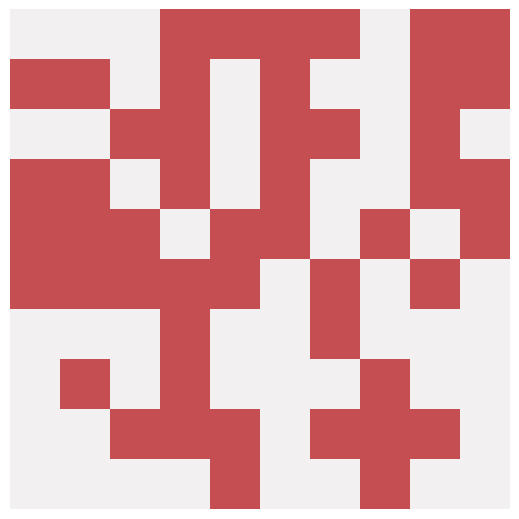

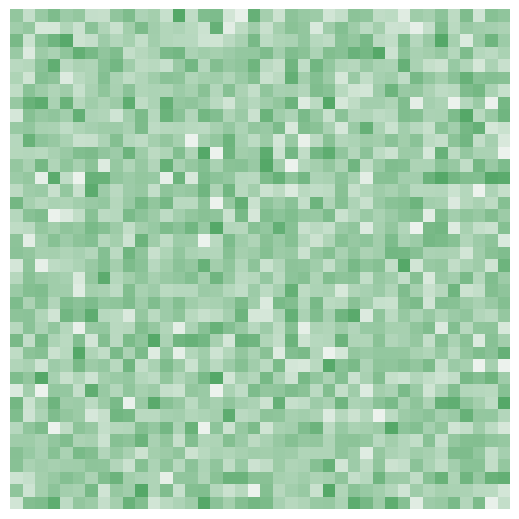

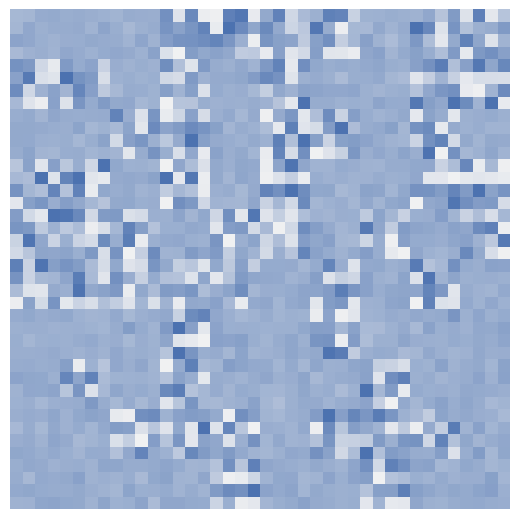

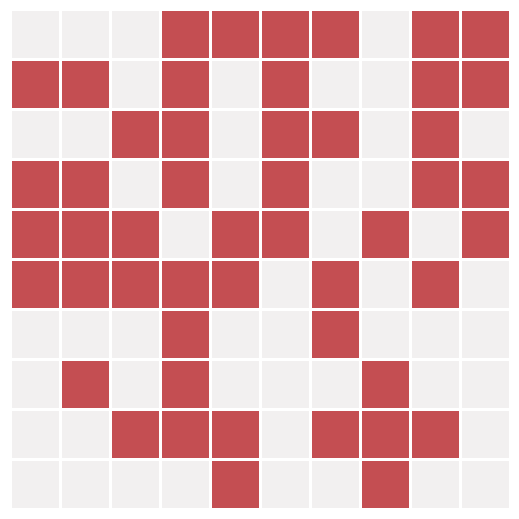

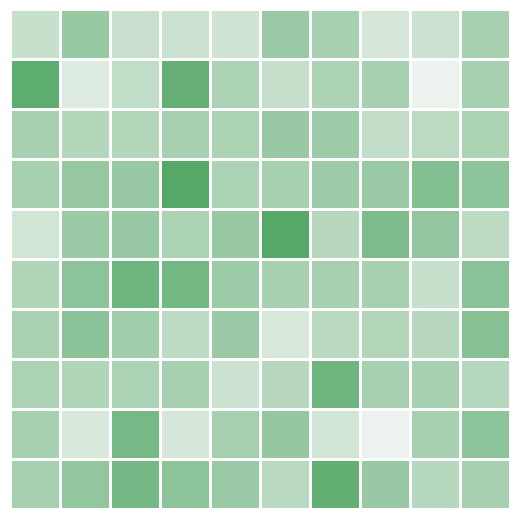

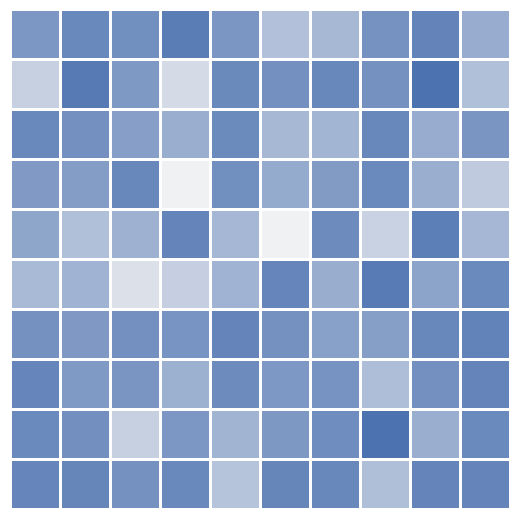

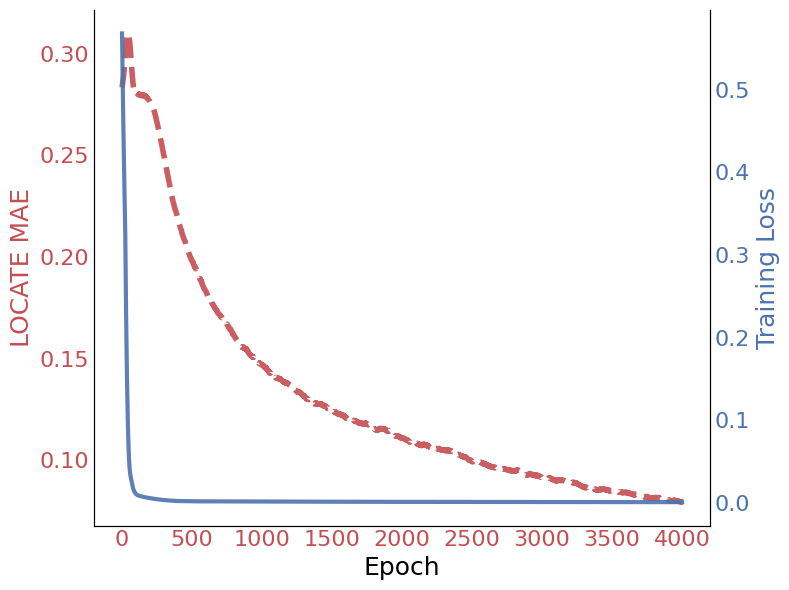

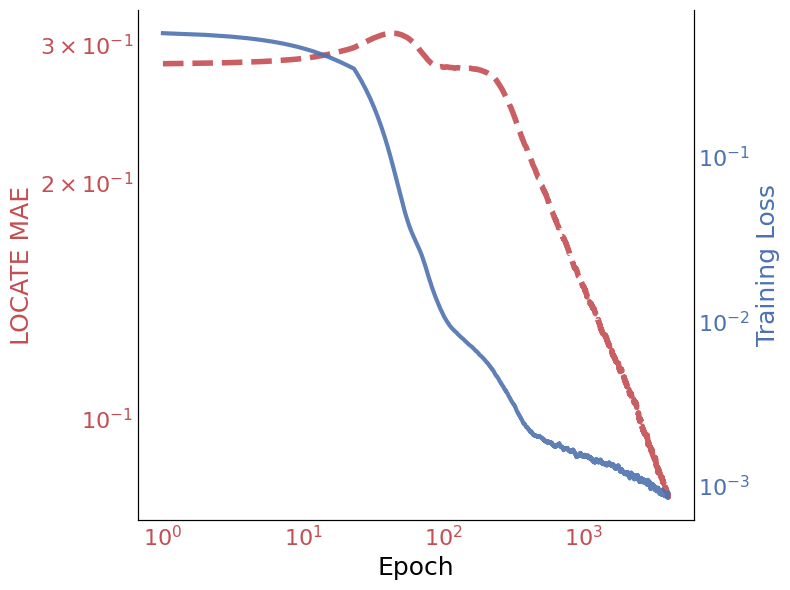

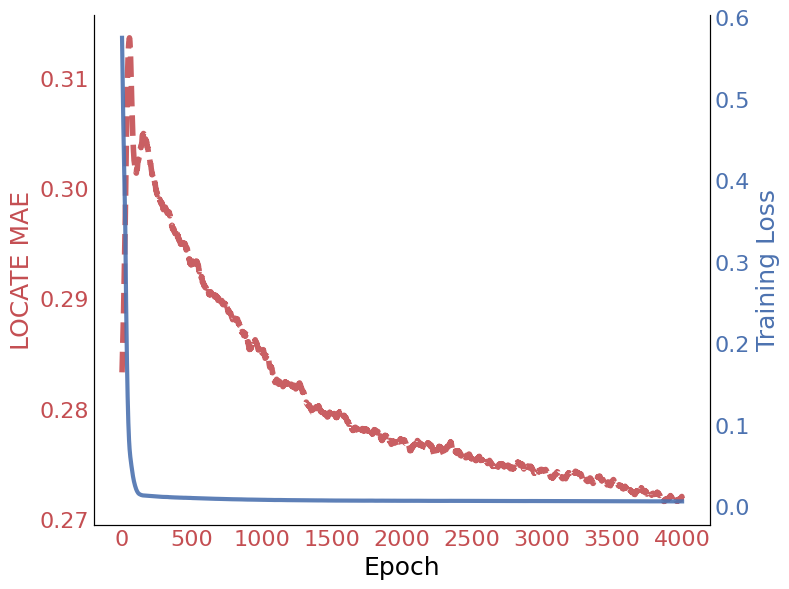

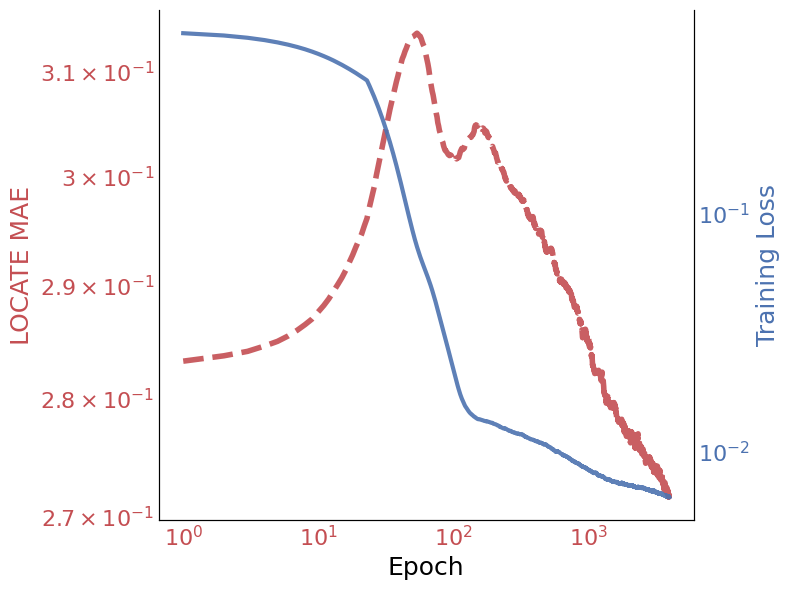

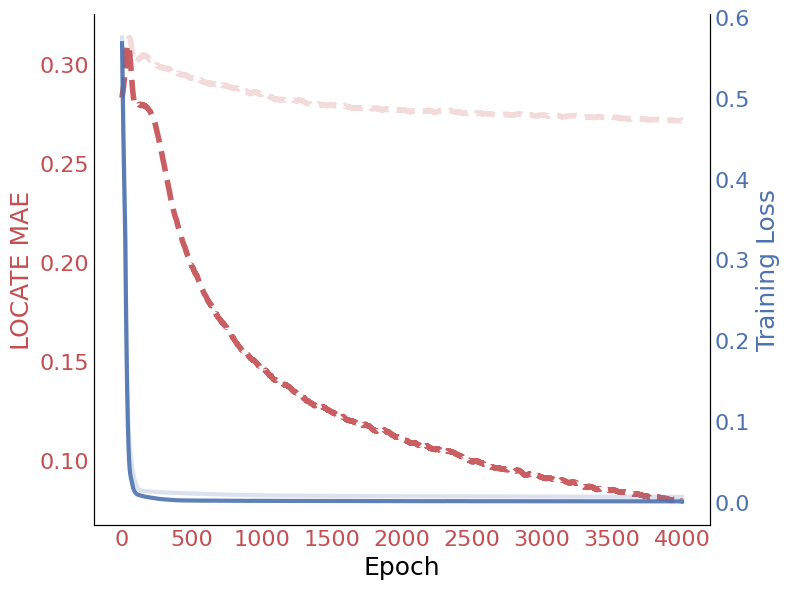

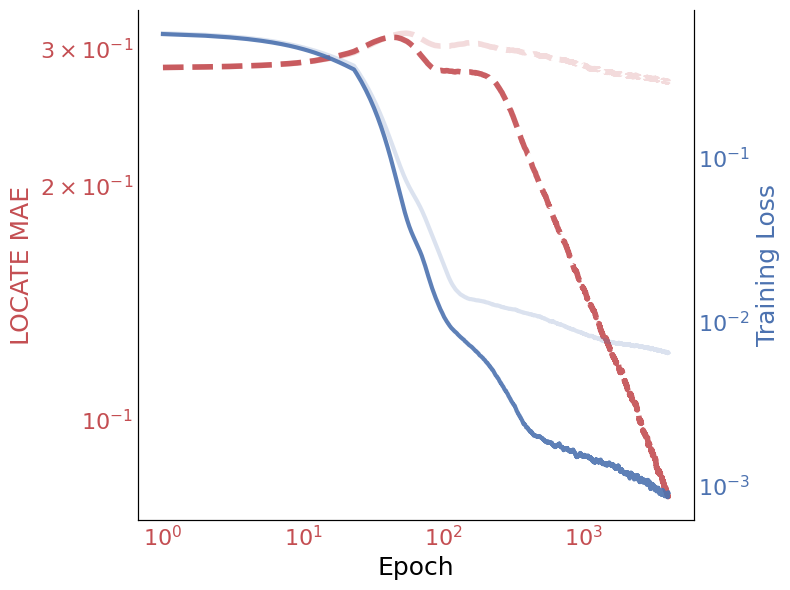

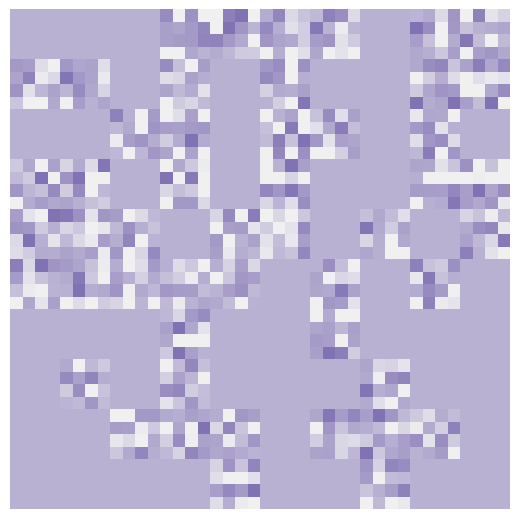

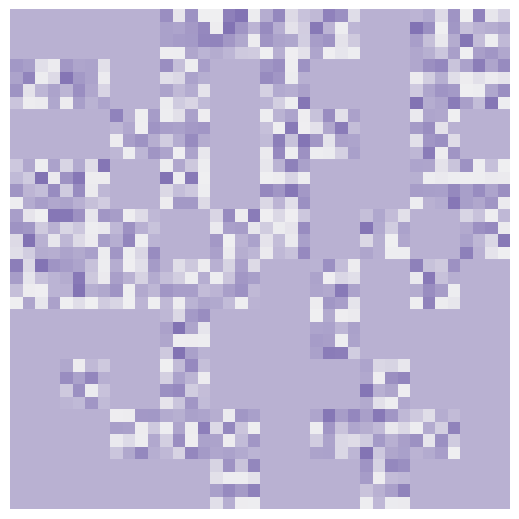

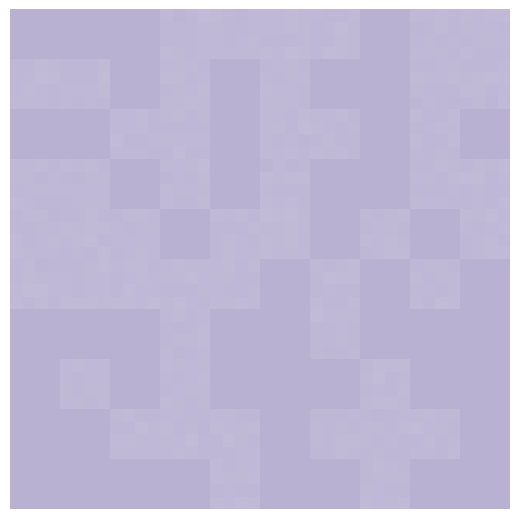


Done. Plots saved to: exp1


In [18]:
# ============================================================
# Cell 2: Read CSV outputs and create JPG/PDF plots
# ============================================================

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch


# ============================================================
# Parameters
# ============================================================

EXP_DIR = "exp1"
ROW = 100
COL = 16

SMOOTHING_WINDOW = 45  # Moving-average window for smoothing loss curves. Use 1 for no smoothing.

row_side = int(math.sqrt(ROW))
col_side = int(math.sqrt(COL))
grid_side = row_side * col_side

if row_side * row_side != ROW:
    raise ValueError(f"ROW={ROW} must be a perfect square.")

if col_side * col_side != COL:
    raise ValueError(f"COL={COL} must be a perfect square.")


# ============================================================
# Colors and style
# ============================================================

colors = sns.color_palette("deep")

red_cmap    = sns.light_palette(colors[3], as_cmap=True)  # Red, Treatment
blue_cmap   = sns.light_palette(colors[0], as_cmap=True)  # Blue, Outcome
green_cmap  = sns.light_palette(colors[2], as_cmap=True)  # Green, Context
pink_cmap   = sns.light_palette(colors[4], as_cmap=True)  # Pink, Backup / LOCATE
purple_cmap = sns.light_palette(colors[4], as_cmap=True)  # Purple, Backup
orange_cmap = sns.light_palette(colors[1], as_cmap=True)  # Orange, Backup

blue_color = colors[0]
red_color = colors[3]


# ============================================================
# Load CSV files
# ============================================================

def read_matrix(name):
    return pd.read_csv(os.path.join(EXP_DIR, name), header=None).values


def read_vector(name):
    return pd.read_csv(os.path.join(EXP_DIR, name), header=None).values.squeeze()


T = read_matrix("T.csv")
C = read_matrix("C.csv")
Y = read_matrix("Y.csv")

T_agg = read_vector("T_agg.csv")
C_agg = read_vector("C_agg.csv")
Y_agg = read_vector("Y_agg.csv")

E_true = read_matrix("LOCATE_true.csv")
E_1a = read_matrix("LOCATE_1a.csv")
E_1b = read_matrix("LOCATE_1b.csv")

hist_1a = pd.read_csv(os.path.join(EXP_DIR, "history_1a.csv"))
hist_1b = pd.read_csv(os.path.join(EXP_DIR, "history_1b.csv"))


# ============================================================
# Grid conversion functions
# ============================================================

def matrix_to_grid(M):
    """
    Convert ROW x COL matrix into spatial grid.

    ROW regions form sqrt(ROW) x sqrt(ROW).
    COL subregions form sqrt(COL) x sqrt(COL) inside each region.
    """
    M = np.asarray(M)

    if M.shape != (ROW, COL):
        raise ValueError(f"Expected matrix shape {(ROW, COL)}, got {M.shape}.")

    grid = np.zeros((grid_side, grid_side), dtype=float)

    for r in range(ROW):
        region_row = r // row_side
        region_col = r % row_side

        start_i = region_row * col_side
        start_j = region_col * col_side

        block = M[r].reshape(col_side, col_side)

        grid[
            start_i:start_i + col_side,
            start_j:start_j + col_side,
        ] = block

    return grid


def vector_to_regional_grid(v):
    """
    Convert length-ROW vector into sqrt(ROW) x sqrt(ROW) grid.
    """
    v = np.asarray(v)

    if v.shape[0] != ROW:
        raise ValueError(f"Expected vector of length {ROW}, got {v.shape[0]}.")

    return v.reshape(row_side, row_side)


# ============================================================
# Plotting helpers
# ============================================================

def save_heatmap(
    data,
    cmap,
    filename,
    figsize=(5, 5),
    vmin=None,
    vmax=None,
    linewidths=0,
    cbar=False,
):
    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        data,
        ax=ax,
        cmap=cmap,
        square=True,
        linewidths=linewidths,
        cbar=cbar,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.tight_layout(pad=0)

    fig.savefig(os.path.join(EXP_DIR, f"{filename}.jpg"), dpi=300, bbox_inches="tight", pad_inches=0)
    fig.savefig(os.path.join(EXP_DIR, f"{filename}.pdf"), bbox_inches="tight", pad_inches=0)

    plt.show()
    plt.close(fig)


def smooth_curve(values, window=25):
    """
    Smooth a 1D curve using a centered moving average.
    """
    values = np.asarray(values, dtype=float)

    if window <= 1:
        return values

    return pd.Series(values).rolling(
        window=window,
        center=True,
        min_periods=1,
    ).mean().values


def save_loss_plot(history, filename, loglog=False):
    """
    Plot smoothed LOCATE MAE on left y-axis and
    smoothed training loss on right y-axis.
    """
    epochs = history["epoch"].values
    training_loss = smooth_curve(history["training_loss"].values, SMOOTHING_WINDOW)
    locate_mae = smooth_curve(history["locate_mae"].values, SMOOTHING_WINDOW)

    fig, ax_left = plt.subplots(figsize=(8, 6))

    ax_left.set_xlabel("Epoch", fontsize=18)
    ax_left.set_ylabel("LOCATE MAE", fontsize=18, color=red_color)

    if loglog:
        ax_left.loglog(
            epochs,
            locate_mae,
            color=red_color,
            linestyle="--",
            linewidth=4,
            alpha=0.9,
        )
    else:
        ax_left.plot(
            epochs,
            locate_mae,
            color=red_color,
            linestyle="--",
            linewidth=4,
            alpha=0.9,
        )

    ax_left.tick_params(axis="both", which="both", length=0, labelsize=16, colors=red_color)
    ax_left.spines["top"].set_visible(False)

    ax_right = ax_left.twinx()
    ax_right.set_ylabel("Training Loss", fontsize=18, color=blue_color)

    if loglog:
        ax_right.loglog(
            epochs,
            training_loss,
            color=blue_color,
            linestyle="-",
            linewidth=3,
            alpha=0.9,
        )
    else:
        ax_right.plot(
            epochs,
            training_loss,
            color=blue_color,
            linestyle="-",
            linewidth=3,
            alpha=0.9,
        )

    ax_right.tick_params(axis="y", which="both", length=0, labelsize=16, colors=blue_color)
    ax_right.spines["top"].set_visible(False)

    plt.tight_layout()

    fig.savefig(os.path.join(EXP_DIR, f"{filename}.jpg"), dpi=300, bbox_inches="tight")
    fig.savefig(os.path.join(EXP_DIR, f"{filename}.pdf"), bbox_inches="tight")

    plt.show()
    plt.close(fig)


def save_combined_loss_plot(hist_1a, hist_1b, filename, loglog=False):
    """
    Combined smoothed loss curve.

    Exp 1a is full opacity.
    Exp 1b is 20% opacity.
    """
    epochs = hist_1a["epoch"].values

    locate_mae_1a = smooth_curve(hist_1a["locate_mae"].values, SMOOTHING_WINDOW)
    locate_mae_1b = smooth_curve(hist_1b["locate_mae"].values, SMOOTHING_WINDOW)

    train_loss_1a = smooth_curve(hist_1a["training_loss"].values, SMOOTHING_WINDOW)
    train_loss_1b = smooth_curve(hist_1b["training_loss"].values, SMOOTHING_WINDOW)

    fig, ax_left = plt.subplots(figsize=(8, 6))

    ax_left.set_xlabel("Epoch", fontsize=18)
    ax_left.set_ylabel("LOCATE MAE", fontsize=18, color=red_color)

    plot_fn_left = ax_left.loglog if loglog else ax_left.plot

    plot_fn_left(
        epochs,
        locate_mae_1a,
        color=red_color,
        linestyle="--",
        linewidth=4,
        alpha=0.9,
    )

    plot_fn_left(
        epochs,
        locate_mae_1b,
        color=red_color,
        linestyle="--",
        linewidth=4,
        alpha=0.2,
    )

    ax_left.tick_params(axis="both", which="both", length=0, labelsize=16, colors=red_color)
    ax_left.spines["top"].set_visible(False)

    ax_right = ax_left.twinx()
    ax_right.set_ylabel("Training Loss", fontsize=18, color=blue_color)

    plot_fn_right = ax_right.loglog if loglog else ax_right.plot

    plot_fn_right(
        epochs,
        train_loss_1a,
        color=blue_color,
        linestyle="-",
        linewidth=3,
        alpha=0.9,
    )

    plot_fn_right(
        epochs,
        train_loss_1b,
        color=blue_color,
        linestyle="-",
        linewidth=3,
        alpha=0.2,
    )

    ax_right.tick_params(axis="y", which="both", length=0, labelsize=16, colors=blue_color)
    ax_right.spines["top"].set_visible(False)

    plt.tight_layout()

    fig.savefig(os.path.join(EXP_DIR, f"{filename}.jpg"), dpi=300, bbox_inches="tight")
    fig.savefig(os.path.join(EXP_DIR, f"{filename}.pdf"), bbox_inches="tight")

    plt.show()
    plt.close(fig)


# ============================================================
# Input matrix heatmaps
# ============================================================

save_heatmap(
    matrix_to_grid(T),
    red_cmap,
    "T_grid",
    figsize=(5, 5),
    vmin=0,
    vmax=1,
    linewidths=0,
    cbar=False,
)

save_heatmap(
    matrix_to_grid(C),
    green_cmap,
    "C_grid",
    figsize=(5, 5),
    vmin=np.percentile(C, 1),
    vmax=np.percentile(C, 99),
    linewidths=0,
    cbar=False,
)

save_heatmap(
    matrix_to_grid(Y),
    blue_cmap,
    "Y_grid",
    figsize=(5, 5),
    vmin=np.percentile(Y, 1),
    vmax=np.percentile(Y, 99),
    linewidths=0,
    cbar=False,
)


# ============================================================
# Aggregated vector heatmaps
# ============================================================

save_heatmap(
    vector_to_regional_grid(T_agg),
    red_cmap,
    "T_agg_grid",
    figsize=(5, 5),
    vmin=0,
    vmax=1,
    linewidths=1,
    cbar=False,
)

save_heatmap(
    vector_to_regional_grid(C_agg),
    green_cmap,
    "C_agg_grid",
    figsize=(5, 5),
    vmin=np.percentile(C_agg, 1),
    vmax=np.percentile(C_agg, 99),
    linewidths=1,
    cbar=False,
)

save_heatmap(
    vector_to_regional_grid(Y_agg),
    blue_cmap,
    "Y_agg_grid",
    figsize=(5, 5),
    vmin=np.percentile(Y_agg, 1),
    vmax=np.percentile(Y_agg, 99),
    linewidths=1,
    cbar=False,
)


# ============================================================
# Loss curves
# ============================================================

save_loss_plot(hist_1a, "loss_1a_linear", loglog=False)
save_loss_plot(hist_1a, "loss_1a_loglog", loglog=True)

save_loss_plot(hist_1b, "loss_1b_linear", loglog=False)
save_loss_plot(hist_1b, "loss_1b_loglog", loglog=True)

save_combined_loss_plot(hist_1a, hist_1b, "loss_combined_linear", loglog=False)
save_combined_loss_plot(hist_1a, hist_1b, "loss_combined_loglog", loglog=True)


# ============================================================
# LOCATE matrix heatmaps
# ============================================================

locate_min = min(E_true.min(), E_1a.min(), E_1b.min())
locate_max = max(E_true.max(), E_1a.max(), E_1b.max())

save_heatmap(
    matrix_to_grid(E_true),
    pink_cmap,
    "LOCATE_true_grid",
    figsize=(5, 5),
    vmin=locate_min,
    vmax=locate_max,
    linewidths=0,
    cbar=False,
)

save_heatmap(
    matrix_to_grid(E_1a),
    pink_cmap,
    "LOCATE_1a_grid",
    figsize=(5, 5),
    vmin=locate_min,
    vmax=locate_max,
    linewidths=0,
    cbar=False,
)

save_heatmap(
    matrix_to_grid(E_1b),
    pink_cmap,
    "LOCATE_1b_grid",
    figsize=(5, 5),
    vmin=locate_min,
    vmax=locate_max,
    linewidths=0,
    cbar=False,
)


print("\nDone. Plots saved to:", EXP_DIR)

### Counterfactual

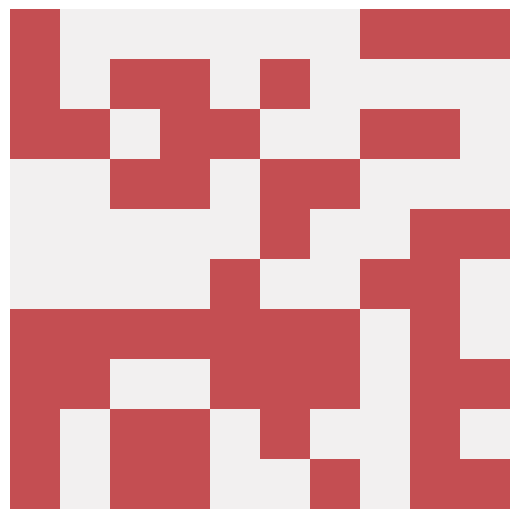

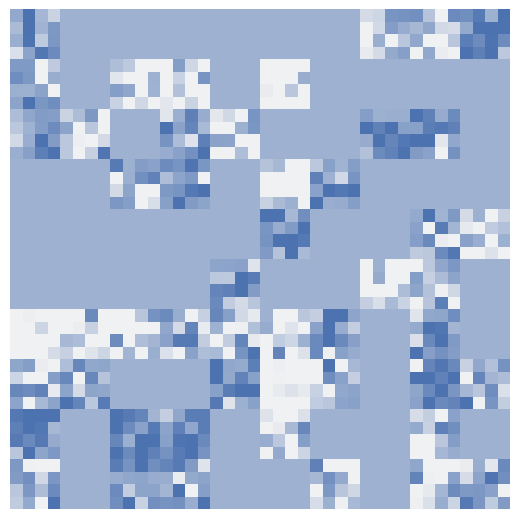

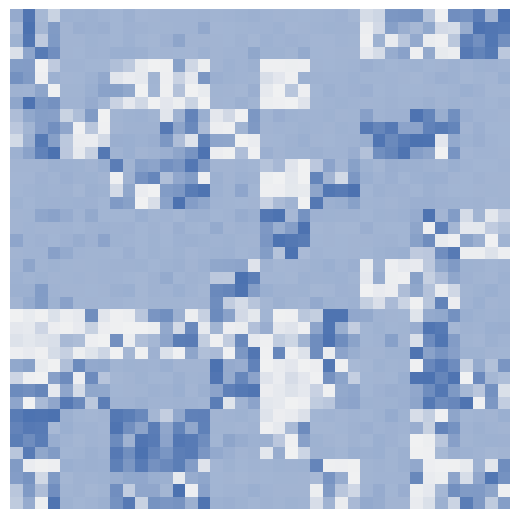


Done. Counterfactual plots saved to: exp1


In [22]:
# ============================================================
# Cell 2b: Counterfactual visualization for Exp 1a
# ============================================================

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# Parameters
# ============================================================

EXP_DIR = "exp1"
ROW = 100
COL = 16

row_side = int(math.sqrt(ROW))
col_side = int(math.sqrt(COL))
grid_side = row_side * col_side

if row_side * row_side != ROW:
    raise ValueError(f"ROW={ROW} must be a perfect square.")

if col_side * col_side != COL:
    raise ValueError(f"COL={COL} must be a perfect square.")


# ============================================================
# Colors and style
# ============================================================

colors = sns.color_palette("deep")

red_cmap  = sns.light_palette(colors[3], as_cmap=True)  # Red, Treatment
blue_cmap = sns.light_palette(colors[0], as_cmap=True)  # Blue, Outcome


# ============================================================
# Grid conversion
# ============================================================

def matrix_to_grid(M):
    """
    Convert ROW x COL matrix into spatial grid.

    ROW regions form sqrt(ROW) x sqrt(ROW).
    COL subregions form sqrt(COL) x sqrt(COL) inside each region.
    """
    M = np.asarray(M)

    if M.shape != (ROW, COL):
        raise ValueError(f"Expected matrix shape {(ROW, COL)}, got {M.shape}.")

    grid = np.zeros((grid_side, grid_side), dtype=float)

    for r in range(ROW):
        region_row = r // row_side
        region_col = r % row_side

        start_i = region_row * col_side
        start_j = region_col * col_side

        block = M[r].reshape(col_side, col_side)

        grid[
            start_i:start_i + col_side,
            start_j:start_j + col_side,
        ] = block

    return grid


# ============================================================
# Plot helper
# ============================================================

def save_heatmap(
    data,
    cmap,
    filename,
    figsize=(5, 5),
    vmin=None,
    vmax=None,
    linewidths=0,
    cbar=False,
):
    fig, ax = plt.subplots(figsize=figsize)

    sns.heatmap(
        data,
        ax=ax,
        cmap=cmap,
        square=True,
        linewidths=linewidths,
        cbar=cbar,
        vmin=vmin,
        vmax=vmax,
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.tight_layout(pad=0)

    fig.savefig(os.path.join(EXP_DIR, f"{filename}.jpg"), dpi=300, bbox_inches="tight", pad_inches=0)
    fig.savefig(os.path.join(EXP_DIR, f"{filename}.pdf"), bbox_inches="tight", pad_inches=0)

    plt.show()
    plt.close(fig)


# ============================================================
# Counterfactual construction
# ============================================================

# Invert treatment matrix
T_cf = 1.0 - T

# Ground-truth counterfactual outcome
Y_cf_true = true_f_numpy(T_cf, C)

# Estimated counterfactual outcome using learned neural approximation from exp1a
Y_cf_est = predict_matrix(model_1a, T_cf, C)


# ============================================================
# Save counterfactual matrices
# ============================================================

pd.DataFrame(T_cf).to_csv(os.path.join(EXP_DIR, "T_cf.csv"), index=False, header=False)
pd.DataFrame(Y_cf_true).to_csv(os.path.join(EXP_DIR, "Y_cf_true.csv"), index=False, header=False)
pd.DataFrame(Y_cf_est).to_csv(os.path.join(EXP_DIR, "Y_cf_est_1a.csv"), index=False, header=False)


# ============================================================
# Counterfactual heatmaps
# ============================================================

# Inverted treatment matrix
save_heatmap(
    matrix_to_grid(T_cf),
    red_cmap,
    "T_cf_grid",
    figsize=(5, 5),
    vmin=0,
    vmax=1,
    linewidths=0,
    cbar=False,
)

# Use shared color scale for true and estimated counterfactual outcomes
y_cf_min = min(Y_cf_true.min(), Y_cf_est.min())
y_cf_max = max(Y_cf_true.max(), Y_cf_est.max())

save_heatmap(
    matrix_to_grid(Y_cf_true),
    blue_cmap,
    "Y_cf_true_grid",
    figsize=(5, 5),
    vmin=y_cf_min,
    vmax=y_cf_max,
    linewidths=0,
    cbar=False,
)

save_heatmap(
    matrix_to_grid(Y_cf_est),
    blue_cmap,
    "Y_cf_est_1a_grid",
    figsize=(5, 5),
    vmin=y_cf_min,
    vmax=y_cf_max,
    linewidths=0,
    cbar=False,
)


print("\nDone. Counterfactual plots saved to:", EXP_DIR)

### Ablation

In [24]:
# ============================================================
# Cell 1: Run exp1c experiments and save CSV outputs
# ============================================================

import os
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# Hyperparameters and parameters
# ============================================================

ROW = 100
COL = 100

EXP_DIR = "exp1"
EXP1C_DIR = os.path.join(EXP_DIR, "exp1c")

SEEDS = list(range(42, 47))  # 10 seeds: 42, ..., 51

REG_STD_VALUES = np.round(np.arange(0.1, 1.01, 0.1), 1)
SUBREG_STD_VALUES = np.round(np.arange(0.1, 1.01, 0.1), 1)

NOISE_STD = 0.1              # Gaussian noise added to Y
FINAL_C_NOISE_STD = 1e-3     # Tiny final noise added to C after exact scaling

N_EPOCHS = 2000
LR = 1e-3
WEIGHT_DECAY = 1e-3
HIDDEN_DIM = 32
DROPOUT = 0.05

PRINT_INTERVAL = 1000        # Less verbose than exp1a because exp1c runs many experiments

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# ============================================================
# Reproducibility
# ============================================================

def set_all_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass


# ============================================================
# Validation and folders
# ============================================================

def is_perfect_square(x):
    r = int(math.sqrt(x))
    return r * r == x


if not is_perfect_square(ROW):
    raise ValueError(f"ROW={ROW} must be a perfect square.")

if not is_perfect_square(COL):
    raise ValueError(f"COL={COL} must be a perfect square.")

os.makedirs(EXP1C_DIR, exist_ok=True)


# ============================================================
# Filename helper
# ============================================================

def fmt_float(x):
    return f"{x:.1f}".replace(".", "p")


def make_suffix(seed, reg_std, subreg_std):
    return f"seed{seed}_reg{fmt_float(reg_std)}_sub{fmt_float(subreg_std)}"


# ============================================================
# Ground-truth function f(t, c)
# ============================================================

def true_f_numpy(t, c):
    """
    Ground-truth function.

    If t == 0:
        f = 1

    If t == 1:
        f is given by piecewise linear interpolation over c
        using anchor points:
            (-100, 2), (-2, 2), (0, 1), (1, 0), (100, 0)
    """
    t = np.asarray(t)
    c = np.asarray(c)

    anchor_x = np.array([-100, -2, 0, 1, 100], dtype=float)
    anchor_y = np.array([2, 2, 1, 0, 0], dtype=float)

    y_t1 = np.interp(c, anchor_x, anchor_y)
    y = np.where(t == 0, 1.0, y_t1)

    return y.astype(float)


# ============================================================
# Data generation
# ============================================================

def create_treatment_matrix(row, col):
    """
    Create treatment matrix T.

    Exactly half of the rows are all ones and half are all zeros.
    """
    if row % 2 != 0:
        raise ValueError("ROW must be even to assign exactly half treated rows.")

    row_flags = np.array([1] * (row // 2) + [0] * (row // 2))
    np.random.shuffle(row_flags)

    T = np.repeat(row_flags[:, None], col, axis=1)

    return T.astype(float)


def zscore_to_std(x, target_std, axis=None, keepdims=False, eps=1e-12):
    """
    Z-score x and multiply by target_std.
    Uses population std, matching np.std default ddof=0.
    """
    x = np.asarray(x, dtype=float)
    mean = x.mean(axis=axis, keepdims=keepdims)
    std = x.std(axis=axis, keepdims=keepdims)

    std_safe = np.where(std < eps, 1.0, std)

    return (x - mean) / std_safe * target_std


def create_context_matrix_exp1c(row, col, reg_std, subreg_std, final_noise_std=1e-3):
    """
    Create context matrix C for exp1c.

    Target properties before final tiny noise:

    1. The row means have std exactly reg_std.
    2. Within each row, the std over columns is exactly subreg_std.
    3. The row means are preserved while scaling within-row deviations.
    4. A tiny final noise is added at the end.
    """

    # --------------------------------------------------------
    # Step 1: Sample one mean per row, z-score, scale to reg_std
    # --------------------------------------------------------
    row_means = np.random.normal(loc=0.0, scale=1.0, size=(row, 1))
    row_means = zscore_to_std(row_means, target_std=reg_std, axis=0, keepdims=True)

    # --------------------------------------------------------
    # Step 2: Sample within-row deviations
    # --------------------------------------------------------
    deviations = np.random.normal(loc=0.0, scale=1.0, size=(row, col))

    # Remove row means so deviations have row mean zero
    deviations = deviations - deviations.mean(axis=1, keepdims=True)

    # Scale each row to have exact std subreg_std over columns
    row_stds = deviations.std(axis=1, keepdims=True)

    if np.any(row_stds < 1e-12):
        raise RuntimeError("A sampled row had near-zero std. Re-run with a different seed.")

    deviations = deviations / row_stds * subreg_std

    # --------------------------------------------------------
    # Step 3: Add deviations to row means.
    # This preserves row means exactly before final noise.
    # --------------------------------------------------------
    C = row_means + deviations

    # --------------------------------------------------------
    # Step 4: Add final tiny noise
    # --------------------------------------------------------
    if final_noise_std > 0:
        C = C + np.random.normal(loc=0.0, scale=final_noise_std, size=(row, col))

    return C.astype(float)


def generate_data(seed, reg_std, subreg_std):
    """
    Generate one full exp1c dataset.
    """
    set_all_seeds(seed)

    T = create_treatment_matrix(ROW, COL)
    C = create_context_matrix_exp1c(
        ROW,
        COL,
        reg_std=reg_std,
        subreg_std=subreg_std,
        final_noise_std=FINAL_C_NOISE_STD,
    )

    Y_clean = true_f_numpy(T, C)
    Y = Y_clean + np.random.normal(loc=0.0, scale=NOISE_STD, size=(ROW, COL))

    T_agg = T.mean(axis=1)
    C_agg = C.mean(axis=1)
    Y_agg = Y.mean(axis=1)

    Y_disagg = np.repeat(Y_agg[:, None], COL, axis=1)

    E_true = true_f_numpy(T, C) - true_f_numpy(np.zeros_like(T), C)

    return {
        "T": T,
        "C": C,
        "Y": Y,
        "Y_clean": Y_clean,
        "T_agg": T_agg,
        "C_agg": C_agg,
        "Y_agg": Y_agg,
        "Y_disagg": Y_disagg,
        "E_true": E_true,
    }


# ============================================================
# Model
# ============================================================

class SmallMLP(nn.Module):
    """
    Simple neural network approximating f(t, c).
    """
    def __init__(self, hidden_dim=64, dropout=0.05):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


def make_features(T, C):
    """
    Convert T and C matrices into feature tensor with shape ROW x COL x 2.
    """
    X = np.stack([T, C], axis=-1)
    return X.astype(np.float32)


def predict_matrix(model, T_np, C_np):
    """
    Predict element-wise outcome matrix using model f_rec(t, c).
    """
    model.eval()

    X_np = make_features(T_np, C_np)
    X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)

    with torch.no_grad():
        pred = model(X_t.reshape(-1, 2)).reshape(T_np.shape)

    return pred.detach().cpu().numpy()


def compute_locate_matrix(model, T_np, C_np):
    """
    Compute LOCATE:
        E_ij = f_rec(t_ij, c_ij) - f_rec(0, c_ij)
    """
    Y_treated_or_observed = predict_matrix(model, T_np, C_np)
    Y_control = predict_matrix(model, np.zeros_like(T_np), C_np)

    return Y_treated_or_observed - Y_control


def compute_locate_mae_torch(model, T_t, C_t, E_true_t):
    """
    Compute current LOCATE MAE during training.
    """
    X_obs = torch.stack([T_t, C_t], dim=-1)
    X_zero = torch.stack([torch.zeros_like(T_t), C_t], dim=-1)

    pred_obs = model(X_obs.reshape(-1, 2)).reshape(T_t.shape)
    pred_zero = model(X_zero.reshape(-1, 2)).reshape(T_t.shape)

    E_pred = pred_obs - pred_zero
    locate_mae = torch.mean(torch.abs(E_pred - E_true_t))

    return locate_mae


# ============================================================
# Experiment 1c: exp1a repeated over reg_std/subreg_std grid
# ============================================================

def train_exp1c_single(T, C, Y, Y_agg, E_true, seed, reg_std, subreg_std):
    """
    Same training objective as exp1a:
    train f_rec using only row-aggregated outcome loss.
    """
    set_all_seeds(seed)

    model = SmallMLP(hidden_dim=HIDDEN_DIM, dropout=DROPOUT).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    X_np = make_features(T, C)

    X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
    T_t = torch.tensor(T, dtype=torch.float32, device=DEVICE)
    C_t = torch.tensor(C, dtype=torch.float32, device=DEVICE)
    Y_t = torch.tensor(Y, dtype=torch.float32, device=DEVICE)
    Y_agg_t = torch.tensor(Y_agg, dtype=torch.float32, device=DEVICE)
    E_true_t = torch.tensor(E_true, dtype=torch.float32, device=DEVICE)

    history = []

    for epoch in range(1, N_EPOCHS + 1):
        model.train()

        pred = model(X_t.reshape(-1, 2)).reshape(ROW, COL)
        pred_agg = pred.mean(dim=1)

        loss = torch.mean((pred_agg - Y_agg_t) ** 2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            prediction_error = torch.mean((pred - Y_t) ** 2)
            locate_mae = compute_locate_mae_torch(model, T_t, C_t, E_true_t)

        history.append({
            "seed": seed,
            "reg_std": reg_std,
            "subreg_std": subreg_std,
            "epoch": epoch,
            "training_loss": loss.item(),
            "prediction_error": prediction_error.item(),
            "locate_mae": locate_mae.item(),
        })

        if epoch % PRINT_INTERVAL == 0 or epoch == 1:
            print(
                f"[Exp 1c] seed={seed} | reg_std={reg_std:.1f} | subreg_std={subreg_std:.1f} | "
                f"epoch={epoch:04d} | loss={loss.item():.6f} | "
                f"prediction_error={prediction_error.item():.6f} | "
                f"locate_mae={locate_mae.item():.6f}"
            )

    return model, pd.DataFrame(history)


# ============================================================
# Main loop
# ============================================================

summary_rows = []

total_runs = len(SEEDS) * len(REG_STD_VALUES) * len(SUBREG_STD_VALUES)
run_idx = 0

for seed in SEEDS:
    for reg_std in REG_STD_VALUES:
        for subreg_std in SUBREG_STD_VALUES:
            run_idx += 1

            print(
                f"\n=== Running {run_idx}/{total_runs}: "
                f"seed={seed}, reg_std={reg_std:.1f}, subreg_std={subreg_std:.1f} ==="
            )

            suffix = make_suffix(seed, reg_std, subreg_std)

            data = generate_data(seed, reg_std, subreg_std)

            T = data["T"]
            C = data["C"]
            Y = data["Y"]
            Y_clean = data["Y_clean"]
            T_agg = data["T_agg"]
            C_agg = data["C_agg"]
            Y_agg = data["Y_agg"]
            Y_disagg = data["Y_disagg"]
            E_true = data["E_true"]

            # ------------------------------------------------
            # Save generated data, same style as exp1a
            # ------------------------------------------------
            pd.DataFrame(T).to_csv(os.path.join(EXP1C_DIR, f"T_{suffix}.csv"), index=False, header=False)
            pd.DataFrame(C).to_csv(os.path.join(EXP1C_DIR, f"C_{suffix}.csv"), index=False, header=False)
            pd.DataFrame(Y).to_csv(os.path.join(EXP1C_DIR, f"Y_{suffix}.csv"), index=False, header=False)
            pd.DataFrame(Y_clean).to_csv(os.path.join(EXP1C_DIR, f"Y_clean_{suffix}.csv"), index=False, header=False)

            pd.DataFrame(T_agg).to_csv(os.path.join(EXP1C_DIR, f"T_agg_{suffix}.csv"), index=False, header=False)
            pd.DataFrame(C_agg).to_csv(os.path.join(EXP1C_DIR, f"C_agg_{suffix}.csv"), index=False, header=False)
            pd.DataFrame(Y_agg).to_csv(os.path.join(EXP1C_DIR, f"Y_agg_{suffix}.csv"), index=False, header=False)

            pd.DataFrame(Y_disagg).to_csv(os.path.join(EXP1C_DIR, f"Y_disagg_{suffix}.csv"), index=False, header=False)
            pd.DataFrame(E_true).to_csv(os.path.join(EXP1C_DIR, f"LOCATE_true_{suffix}.csv"), index=False, header=False)

            # ------------------------------------------------
            # Train exp1a-style aggregated-loss model
            # ------------------------------------------------
            model_1c, hist_1c = train_exp1c_single(
                T=T,
                C=C,
                Y=Y,
                Y_agg=Y_agg,
                E_true=E_true,
                seed=seed,
                reg_std=reg_std,
                subreg_std=subreg_std,
            )

            Y_rec_1c = predict_matrix(model_1c, T, C)
            E_1c = compute_locate_matrix(model_1c, T, C)

            hist_1c.to_csv(os.path.join(EXP1C_DIR, f"history_1c_{suffix}.csv"), index=False)
            pd.DataFrame(Y_rec_1c).to_csv(os.path.join(EXP1C_DIR, f"Y_rec_1c_{suffix}.csv"), index=False, header=False)
            pd.DataFrame(E_1c).to_csv(os.path.join(EXP1C_DIR, f"LOCATE_1c_{suffix}.csv"), index=False, header=False)

            final_row = hist_1c.iloc[-1].to_dict()

            # Diagnostics after final noise
            final_row.update({
                "C_row_mean_std_after_noise": C.mean(axis=1).std(),
                "C_within_row_std_mean_after_noise": C.std(axis=1).mean(),
                "C_within_row_std_min_after_noise": C.std(axis=1).min(),
                "C_within_row_std_max_after_noise": C.std(axis=1).max(),
            })

            summary_rows.append(final_row)


# ============================================================
# Save summary and metadata
# ============================================================

summary = pd.DataFrame(summary_rows)
summary.to_csv(os.path.join(EXP1C_DIR, "summary_1c.csv"), index=False)

metadata = pd.DataFrame({
    "parameter": [
        "ROW",
        "COL",
        "SEEDS",
        "REG_STD_VALUES",
        "SUBREG_STD_VALUES",
        "NOISE_STD",
        "FINAL_C_NOISE_STD",
        "N_EPOCHS",
        "LR",
        "WEIGHT_DECAY",
        "HIDDEN_DIM",
        "DROPOUT",
        "PRINT_INTERVAL",
        "DEVICE",
    ],
    "value": [
        ROW,
        COL,
        str(SEEDS),
        str(list(REG_STD_VALUES)),
        str(list(SUBREG_STD_VALUES)),
        NOISE_STD,
        FINAL_C_NOISE_STD,
        N_EPOCHS,
        LR,
        WEIGHT_DECAY,
        HIDDEN_DIM,
        DROPOUT,
        PRINT_INTERVAL,
        DEVICE,
    ],
})

metadata.to_csv(os.path.join(EXP1C_DIR, "metadata_1c.csv"), index=False)

print("\nDone. Exp1c CSV outputs written to:", EXP1C_DIR)


=== Running 1/500: seed=42, reg_std=0.1, subreg_std=0.1 ===
[Exp 1c] seed=42 | reg_std=0.1 | subreg_std=0.1 | epoch=0001 | loss=1.025269 | prediction_error=1.039982 | locate_mae=0.063468


KeyboardInterrupt: 

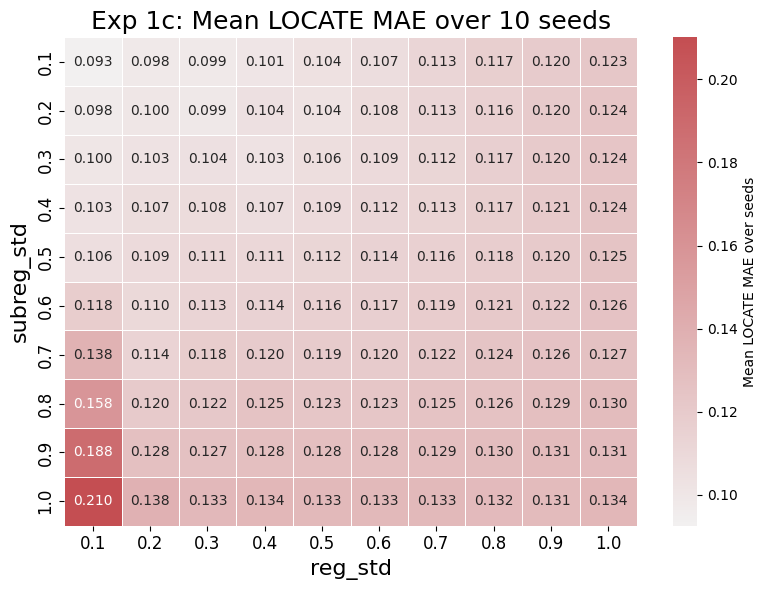


Done. Exp1c heatmap saved to: exp1/exp1c


In [20]:
# ============================================================
# Cell 2: Read exp1c CSV outputs and create aggregate heatmap
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ============================================================
# Parameters
# ============================================================

EXP_DIR = "exp1"
EXP1C_DIR = os.path.join(EXP_DIR, "exp1c")

REG_STD_VALUES = np.round(np.arange(0.1, 1.01, 0.1), 1)
SUBREG_STD_VALUES = np.round(np.arange(0.1, 1.01, 0.1), 1)


# ============================================================
# Colors and style
# ============================================================

colors = sns.color_palette("deep")

red_color = colors[3]
red_cmap = sns.light_palette(red_color, as_cmap=True)


# ============================================================
# Load summary
# ============================================================

summary = pd.read_csv(os.path.join(EXP1C_DIR, "summary_1c.csv"))


# ============================================================
# Aggregate final LOCATE MAE over seeds
# ============================================================

heatmap_df = (
    summary
    .groupby(["subreg_std", "reg_std"], as_index=False)["locate_mae"]
    .mean()
    .pivot(index="subreg_std", columns="reg_std", values="locate_mae")
)

# Ensure fixed axis order
heatmap_df = heatmap_df.loc[SUBREG_STD_VALUES, REG_STD_VALUES]


# ============================================================
# Save numeric aggregate table
# ============================================================

heatmap_df.to_csv(os.path.join(EXP1C_DIR, "locate_mae_mean_heatmap_values_1c.csv"))


# ============================================================
# Plot heatmap
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    heatmap_df,
    ax=ax,
    cmap=red_cmap,
    annot=True,
    fmt=".3f",
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    cbar_kws={"label": "Mean LOCATE MAE over seeds"},
)

ax.set_xlabel("reg_std", fontsize=16)
ax.set_ylabel("subreg_std", fontsize=16)
ax.set_title("Exp 1c: Mean LOCATE MAE over 10 seeds", fontsize=18)

ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()

fig.savefig(os.path.join(EXP1C_DIR, "locate_mae_mean_heatmap_1c.jpg"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(EXP1C_DIR, "locate_mae_mean_heatmap_1c.pdf"), bbox_inches="tight")

plt.show()
plt.close(fig)

print("\nDone. Exp1c heatmap saved to:", EXP1C_DIR)

### Download

In [23]:
# ============================================================
# Zip all of exp1/ in Google Colab
# ============================================================

import os
import shutil
from google.colab import files

EXP_DIR = "exp1"
ZIP_NAME = "exp1_outputs"

if not os.path.exists(EXP_DIR):
    raise FileNotFoundError(f"Could not find folder: {EXP_DIR}")

zip_path = shutil.make_archive(
    base_name=ZIP_NAME,
    format="zip",
    root_dir=".",
    base_dir=EXP_DIR,
)

print(f"Created zip file: {zip_path}")

files.download(zip_path)

Created zip file: /content/exp1_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>